# 05 · Temperature dependence and time-temperature superposition

Viscosity falls steeply with temperature - an engine oil thins several-fold between a cold start and
operating temperature, and a polymer melt's viscosity can change by a factor of ten over 20 K. This
notebook describes that dependence and uses it: for many materials a temperature change merely rescales
time, so measurements at several temperatures combine into a **master curve** covering far more decades
than any single test.

**What you will learn**
- describe the temperature dependence of viscosity with the Arrhenius and Vogel equations
- build a master curve by time-temperature superposition
- fit WLF constants and use shift factors
- recognise when superposition must not be used

**Before you start:** notebooks 00 and 03; logarithms  ·  **Time:** about 60 min

In [1]:
try:                      # on Google Colab (or anywhere engrheo is missing): install it from GitHub
    import engrheo
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engrheo"], check=True)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import optimize
from engrheo import datasets, tts
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

def heading(text):
    print(f"\n{text}\n" + "=" * len(text))

## An engine oil: Arrhenius or not?
A thermally activated flow process gives the Arrhenius law $\eta = A\,e^{E_a/RT}$: a straight line of $\ln\eta$
against $1/T$. Over a wide temperature range liquids often curve away from it; the Vogel(-Fulcher-Tammann)
equation $\eta = A\,e^{B/(T - T_0)}$ captures that.

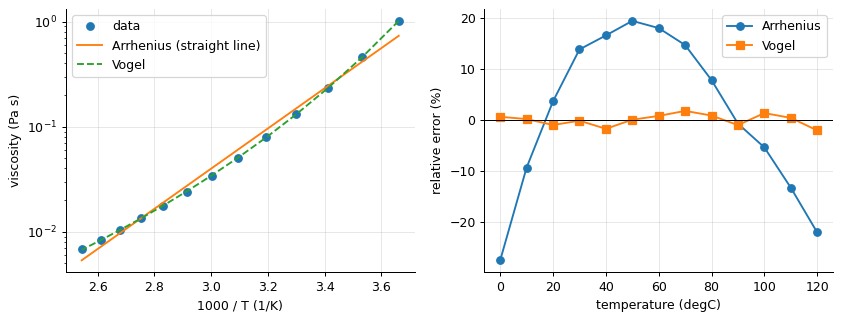

Arrhenius: Ea = 36.6 kJ/mol over the whole range
Vogel: B = 1080 K, T0 = 162 K   (true: 1100 K, 160 K)
local apparent activation energy: 51 kJ/mol at 0 degC, 23 kJ/mol at 120 degC


In [2]:
oil = pd.read_csv(datasets.path("engine_oil_viscosity_temperature.csv"), comment="#")
T = oil.temperature_C.to_numpy() + 273.15
eta = oil.viscosity_Pa_s.to_numpy()
b, a = np.polyfit(1 / T, np.log(eta), 1)                         # Arrhenius: ln eta = a + (Ea/R)/T
vog, _ = optimize.curve_fit(lambda T_, lnA, B, T0: lnA + B / (T_ - T0), T, np.log(eta), p0=[-10, 1000, 150])
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8))
a1.semilogy(1000 / T, eta, "o", label="data")
a1.semilogy(1000 / T, np.exp(a + b / T), label="Arrhenius (straight line)")
a1.semilogy(1000 / T, np.exp(vog[0] + vog[1] / (T - vog[2])), "--", label="Vogel")
a1.set(xlabel="1000 / T (1/K)", ylabel="viscosity (Pa s)"); a1.legend()
a2.plot(T - 273.15, 100 * (np.exp(a + b / T) / eta - 1), "o-", label="Arrhenius")
a2.plot(T - 273.15, 100 * (np.exp(vog[0] + vog[1] / (T - vog[2])) / eta - 1), "s-", label="Vogel")
a2.axhline(0, color="k", lw=0.8); a2.set(xlabel="temperature (degC)", ylabel="relative error (%)"); a2.legend()
plt.show()
print(f"Arrhenius: Ea = {b * tts.R_GAS / 1000:.1f} kJ/mol over the whole range")
print(f"Vogel: B = {vog[1]:.0f} K, T0 = {vog[2]:.0f} K   (true: 1100 K, 160 K)")
local_Ea = np.gradient(np.log(eta), 1 / T) * tts.R_GAS / 1000
print(f"local apparent activation energy: {local_Ea[0]:.0f} kJ/mol at {T[0]-273.15:.0f} degC, {local_Ea[-1]:.0f} kJ/mol at {T[-1]-273.15:.0f} degC")

The Arrhenius line misses systematically - too low at the ends, too high in the middle - because the
apparent activation energy itself falls with temperature. An Arrhenius law is a good *local* description
(over a few tens of kelvin) but not a global one for such liquids.

## A polymer melt: frequency sweeps at six temperatures

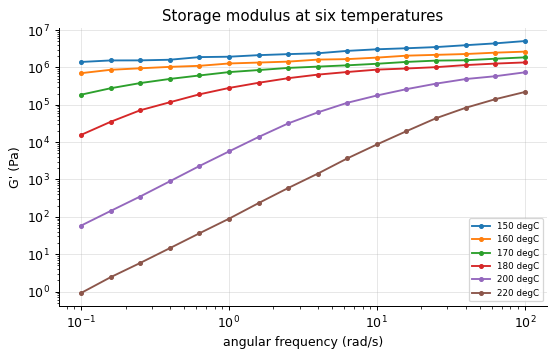

In [3]:
melt = pd.read_csv(datasets.path("polystyrene_frequency_sweeps.csv"), comment="#")
fig, ax = plt.subplots()
for T_C, grp in melt.groupby("temperature_C"):
    ax.loglog(grp.omega_rad_s, grp.G_storage_Pa, "o-", ms=3, label=f"{T_C:.0f} degC")
ax.set(xlabel="angular frequency (rad/s)", ylabel="G' (Pa)", title="Storage modulus at six temperatures"); ax.legend(fontsize=7)
plt.show()

Each curve covers only three decades of frequency, and the curves look like shifted copies of one another.
Shift them horizontally onto the 170 degC curve:

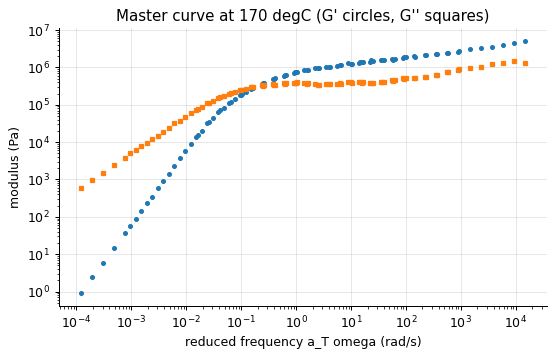

log10 aT: 150 degC: +2.164, 160 degC: +0.953, 170 degC: +0.000, 180 degC: -0.785, 200 degC: -2.015, 220 degC: -2.916
WLF fit: C1 = 8.87, C2 = 102.1 K   (true 8.86, 101.6 K)
the master curve spans 8.1 decades of frequency; each measurement spanned 3


In [4]:
curves = {T_C + 273.15: (g.omega_rad_s.to_numpy(), g[["G_storage_Pa", "G_loss_Pa"]].to_numpy())
          for T_C, g in melt.groupby("temperature_C")}
T_ref = 170 + 273.15
mc = tts.master_curve(curves, T_ref)
fig, ax = plt.subplots()
for T_ in sorted(curves):
    ax.loglog(mc["omega_reduced"][T_], mc["y"][T_][:, 0], "o", ms=3, color="C0")
    ax.loglog(mc["omega_reduced"][T_], mc["y"][T_][:, 1], "s", ms=3, color="C1")
ax.set(xlabel="reduced frequency a_T omega (rad/s)", ylabel="modulus (Pa)", title="Master curve at 170 degC (G' circles, G'' squares)")
plt.show()
temps = np.array(sorted(curves))
laT = np.array([mc["log10_aT"][T_] for T_ in temps])
w = tts.fit_wlf(temps, laT, T_ref)
print("log10 aT:", ", ".join(f"{T_ - 273.15:.0f} degC: {v:+.3f}" for T_, v in zip(temps, laT)))
print(f"WLF fit: C1 = {w['C1']:.2f}, C2 = {w['C2']:.1f} K   (true 8.86, 101.6 K)")
wr = np.concatenate([mc["omega_reduced"][T_] for T_ in temps])
print(f"the master curve spans {np.log10(wr.max() / wr.min()):.1f} decades of frequency; each measurement spanned 3")

The shifted curves superpose onto one master curve spanning several more decades than any single
measurement - from the terminal zone (where the melt flows) to the rubbery plateau. The shift factors
follow the WLF equation, the standard description for polymers between the glass transition and about
100 K above it. (For precise work a small vertical shift $\rho T/\rho_{ref}T_{ref}$ is also applied; it is ignored here.)
The zero-shear viscosity shifts the same way: $\eta_0(T) = a_T\,\eta_0(T_{ref})$.

Superposition is an assumption. It fails for materials whose structure changes with temperature (phase
separation, crystallisation, some blends) - if the shifted curves do not overlap in shape, TTS must not be
forced.

## Inside the algorithm: one shift factor by hand
Shift the 180 degC curve onto the 170 degC curve: try a range of shifts $\log_{10} a$, and for each compare
$\ln G'$ and $\ln G''$ of the shifted curve with the reference curve (interpolated on log scales) where they overlap:

In [5]:
w_ref, y_ref = curves[443.15]; w_180, y_180 = curves[453.15]
trial = np.linspace(-1.5, 0.5, 2001)
def mismatch(la):
    s = np.log10(w_180) + la
    m = (s >= np.log10(w_ref).min()) & (s <= np.log10(w_ref).max())
    return np.mean([(np.log(y_180[m, j]) - np.interp(s[m], np.log10(w_ref), np.log(y_ref[:, j])))**2 for j in (0, 1)])
best = trial[np.argmin([mismatch(v) for v in trial])]
print(f"by hand: log10 aT(180 degC) = {best:.4f};  library: {mc['log10_aT'][453.15]:.4f}")

by hand: log10 aT(180 degC) = -0.7850;  library: -0.7850


## Exercises
1. Fit the Arrhenius law to the engine-oil data between 60 and 120 degC only, and use it to predict the viscosity at 0 degC. By how much is the cold-start viscosity misjudged?
2. With the fitted WLF constants, by what factor does the melt's longest relaxation time change between 170 degC and 220 degC, and between 170 degC and 150 degC? What does that mean for processing?
3. **Implement it yourself:** write `wlf_shift(T, C1, C2, T_ref)` and a function that converts WLF constants from one reference temperature to another ($C_2' = C_2 + T_{ref}' - T_{ref}$, $C_1' = C_1C_2/C_2'$); check that both descriptions give identical shift factors.